In [5]:
#cargar librerias
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estilo general
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Librerías cargadas correctamente ")

Librerías cargadas correctamente 


In [ ]:
# partidos de ligaMX
partidos = pd.read_csv("../data/raw/2016-2024_liga_mx.csv")

# Transfermarkt
players = pd.read_csv("../data/raw/players.csv", low_memory=False)
clubs = pd.read_csv("../data/raw/clubs.csv", low_memory=False)
valuations = pd.read_csv("../data/raw/player_valuations.csv", low_memory=False)

print("partidos:", partidos.shape)
print("players:", players.shape)
print("clubs:", clubs.shape)
print("valuations:", valuations.shape)

partidos: (2876, 23)
players: (47689, 26)
clubs: (796, 17)
valuations: (643696, 6)


In [7]:
#explorar columnas
print("=== PARTIDOS ===")
print(partidos.columns.tolist())
print(partidos.head(3))

print("\n=== PLAYERS ===")
print(players.columns.tolist())

print("\n=== CLUBS ===")
print(clubs.columns.tolist())

print("\n=== VALUATIONS ===")
print(valuations.columns.tolist())

=== PARTIDOS ===
['id', 'referee', 'timezone', 'date', 'venue_id', 'venue_name', 'venue_city', 'season', 'round', 'home_team', 'away_team', 'home_win', 'away_win', 'home_goals', 'away_goals', 'home_goals_half_time', 'away_goals_half_time', 'home_goals_fulltime', 'away_goals_fulltime', 'home_goals_extra_time', 'away_goals_extratime', 'home_goals_penalty', 'away_goals_penalty']
       id       referee timezone                       date  venue_id  \
0  864095   D. Quintero      UTC  2022-07-02T02:05:00+00:00   10546.0   
1  864096      I. Lopez      UTC  2022-07-02T22:00:00+00:00    1076.0   
2  864094  L. Santander      UTC  2022-07-02T22:00:00+00:00    1080.0   

                           venue_name      venue_city  season         round  \
0                 Estadio de Mazatlán        Mazatlán    2022  Apertura - 1   
1                       Estadio AKRON         Zapopan    2022  Apertura - 1   
2  Estadio Victoria de Aguascalientes  Aguascalientes    2022  Apertura - 1   

           

In [ ]:
# limpiar fecha y crear columnas utiles
partidos["date"] = pd.to_datetime(partidos["date"], utc=True)
partidos["year"] = partidos["date"].dt.year

# quitar filas sin goles
partidos = partidos.dropna(subset=["home_goals", "away_goals"])

# resultado para cada equipo
def resultado(row):
    if row["home_goals"] > row["away_goals"]:
        return "local_gana"
    elif row["home_goals"] < row["away_goals"]:
        return "visitante_gana"
    else:
        return "empate"

partidos["resultado"] = partidos.apply(resultado, axis=1)

print(f"Partidos limpios: {len(partidos)}")
print(partidos[["date", "home_team", "away_team", "home_goals", "away_goals", "resultado"]].head())

Partidos limpios: 2813
                       date           home_team  away_team  home_goals  \
0 2022-07-02 02:05:00+00:00            Mazatlán     Puebla         2.0   
1 2022-07-02 22:00:00+00:00  Guadalajara Chivas  FC Juarez         0.0   
2 2022-07-02 22:00:00+00:00              Necaxa     Toluca         1.0   
3 2022-07-03 00:05:00+00:00         Tigres UANL  Cruz Azul         2.0   
4 2022-07-03 02:05:00+00:00        Club America      Atlas         0.0   

   away_goals       resultado  
0         4.0  visitante_gana  
1         0.0          empate  
2         3.0  visitante_gana  
3         3.0  visitante_gana  
4         0.0          empate  


In [9]:
# filtrar solo jugadores de Liga MX
val_mx = valuations[valuations["player_club_domestic_competition_id"] == "MEX1"].copy()
val_mx["date"] = pd.to_datetime(val_mx["date"])
val_mx["year"] = val_mx["date"].dt.year

print(f"Registros de valor de mercado Liga MX: {len(val_mx)}")
print(val_mx["current_club_name"].value_counts().head(10))

Registros de valor de mercado Liga MX: 6138
current_club_name
Tigres UANL              476
CF América               433
CF Pachuca               433
CF Monterrey             417
Deportivo Guadalajara    393
CD Cruz Azul             389
Atlas Guadalajara        374
Santos Laguna            374
Club León FC             345
Club Tijuana             332
Name: count, dtype: int64


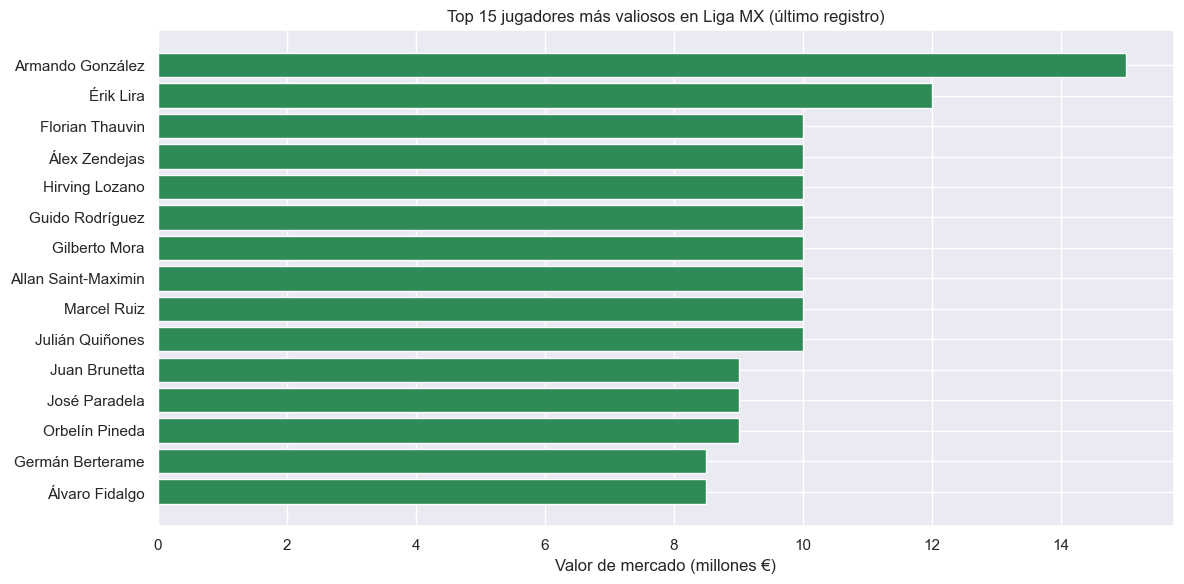

In [13]:
# jugadores mas valiosos de la liga
#  ultimo valor registrado por jugador
ultimo_valor = val_mx.sort_values("date").groupby("player_id").last().reset_index()

# unir con nombres
ultimo_valor = ultimo_valor.merge(
    players[["player_id", "name", "position"]],
    on="player_id", how="left"
)

top_jugadores = ultimo_valor.sort_values("market_value_in_eur", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_jugadores["name"], top_jugadores["market_value_in_eur"] / 1_000_000, color="seagreen")
ax.set_title("Top 15 jugadores más valiosos en Liga MX (último registro)")
ax.set_xlabel("Valor de mercado (millones €)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
#exportar partidos limpios
partidos.to_csv("../data/processed/partidos_limpios.csv", index=False)
print("partidos_limpios.csv exportado")

partidos_limpios.csv exportado


In [15]:
#exportar valuaciones
val_mx.to_csv("../data/processed/valuations_mx.csv", index=False)
print("valuations_mx.csv exportado")

valuations_mx.csv exportado
